# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Zico Diego Rio Ramadhonny | 5054251023 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [55]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import os
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)


In [56]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
path = kagglehub.dataset_download("jamaltariqcheema/pima-indians-diabetes-dataset")

print("Path to dataset files:", path)

dataset_file = None
files_in_path = [os.path.join(path, file) for file in os.listdir(path)]
for file in files_in_path:
    if os.path.isfile(file) and os.path.splitext(os.path.basename(file))[-1] == ".csv":
        dataset_file = file
        break
    
if dataset_file is None:
    raise FileNotFoundError(f"CSV dataset file can't be found at {path}.")

#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.
data = pd.read_csv(dataset_file)
display(data.info())
display(data.describe())

Path to dataset files: /home/zico/.cache/kagglehub/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/versions/1
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


None

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


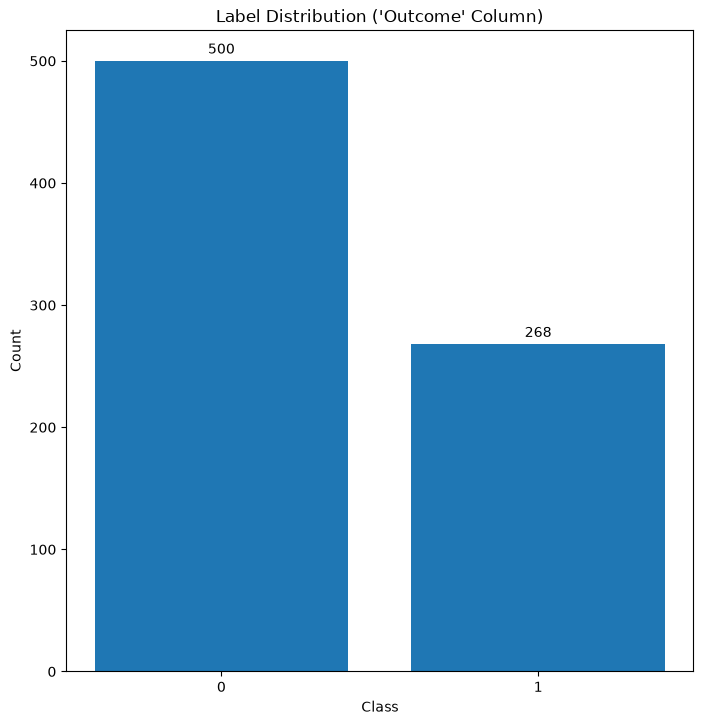

In [57]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 7))
plt.tight_layout()

label = data["Outcome"]
count = label.value_counts()

ax.bar(count.index, count.values, 0.8)
ax.set_title("Label Distribution ('Outcome' Column)")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_xticks(count.index)

for cls_id, n_count in count.items():
    ax.text(cls_id, n_count+6, str(n_count), ha="center")

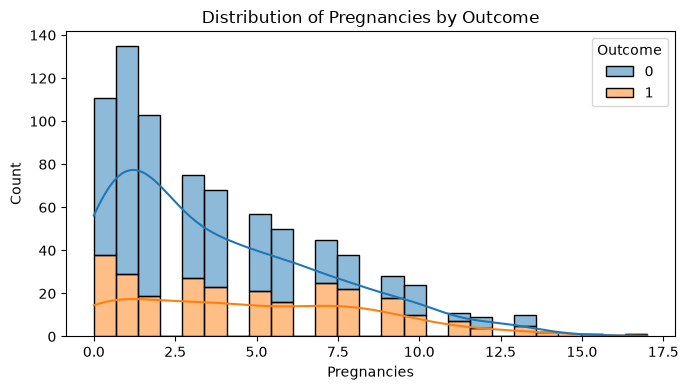

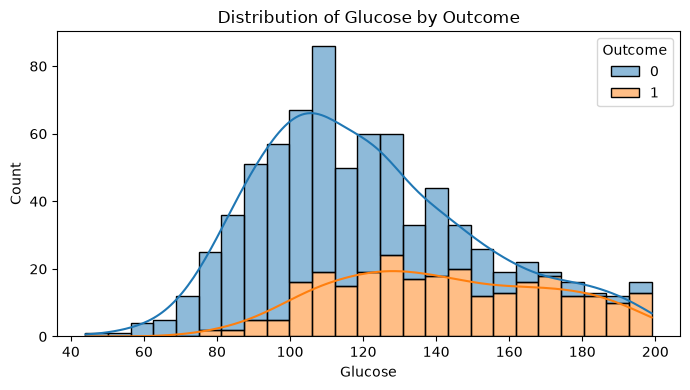

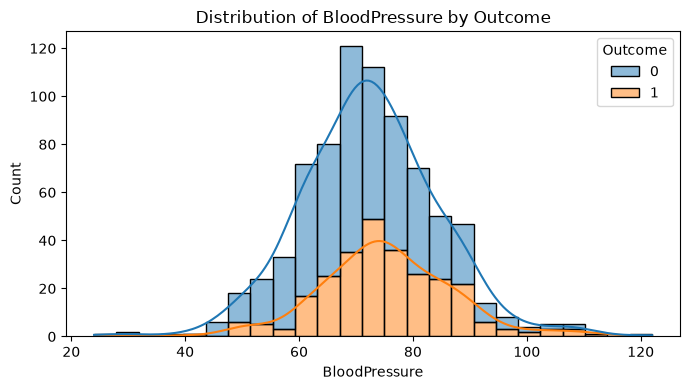

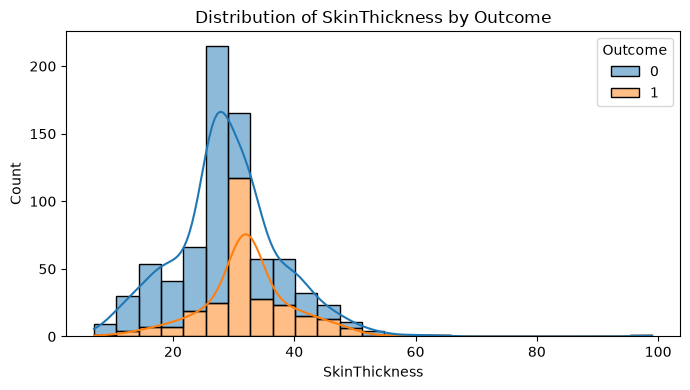

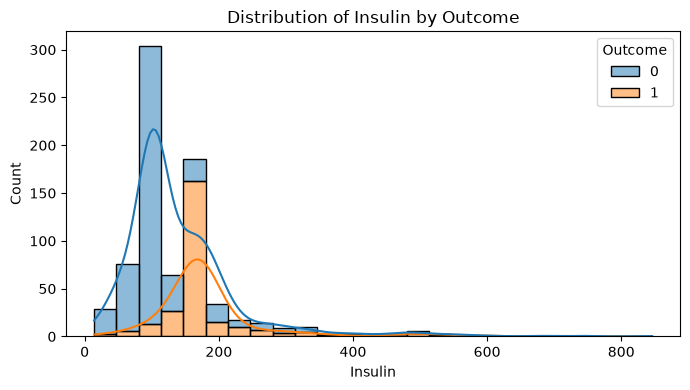

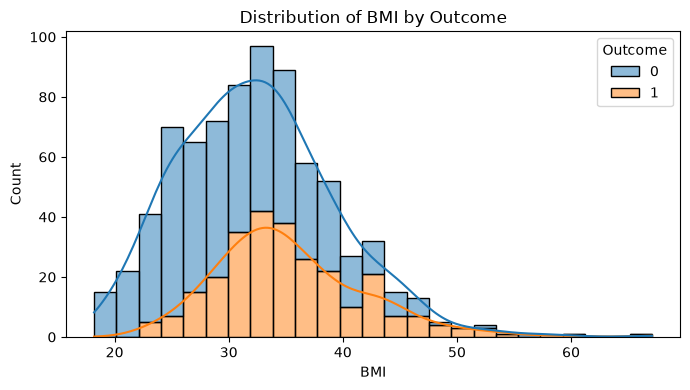

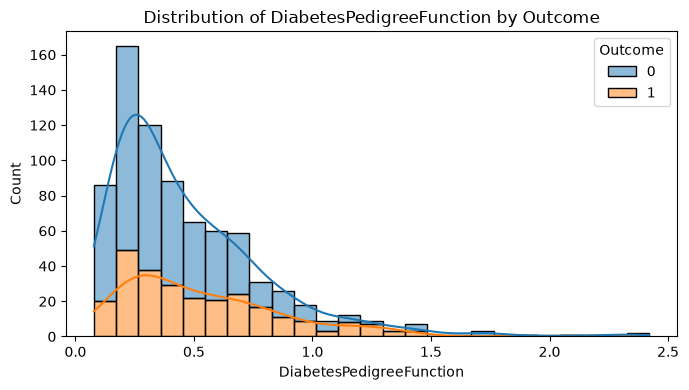

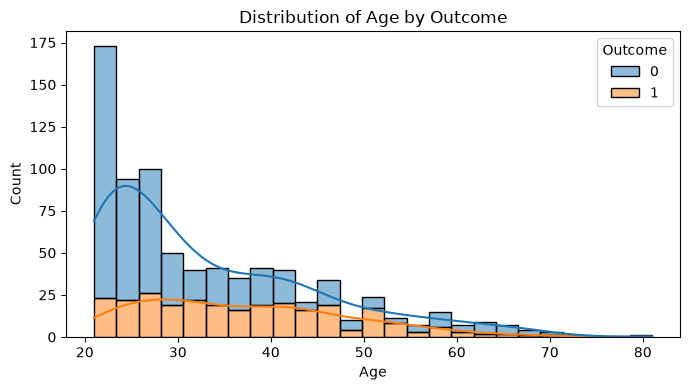

In [58]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
for col in data.columns[:-1]:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=data, x=col, hue="Outcome", bins=25, kde=True, multiple="stack")
    plt.title(f"Distribution of {col} by Outcome")
    plt.tight_layout()
    plt.show()


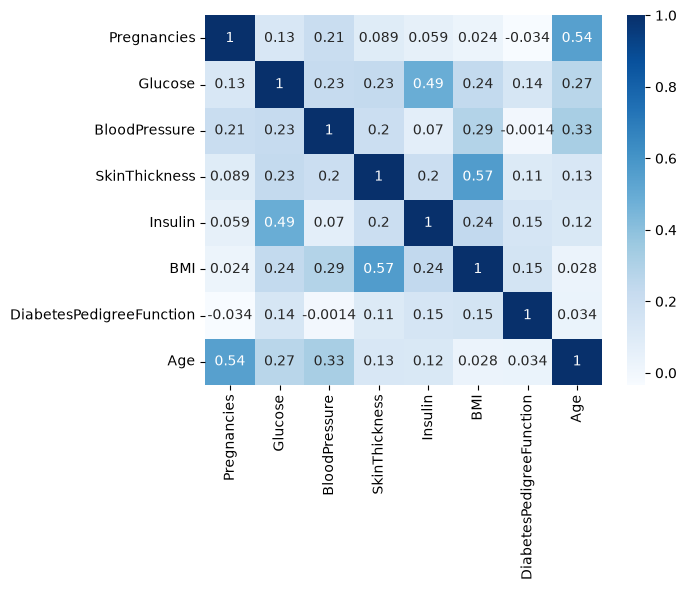

In [59]:
# Tampilkan heatmap korelasi antar fitur.
feat_data = data[[col for col in data.columns if col != "Outcome"]]
feat_coor = feat_data.corr()
h, w = feat_coor.shape

sns.heatmap(feat_coor, cmap="Blues", annot=True)
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [73]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.

feat_col = [col for col in data.columns if col != "Outcome"]
for col in feat_col:
    curr_col              = data[col]
    all_medically_invalid = curr_col.loc[curr_col == 0]
    
    if len(all_medically_invalid) > 0:
        print(f"Column '{col}' has {len(all_medically_invalid)} zero value(s).")
        if col == "Pregnancies":
            print("However, zero times pregnant is still valid.")

Column 'Pregnancies' has 111 zero value(s).
However, zero times pregnant is still valid.


In [61]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

print("No medically invalid values are present, so skipping this step instead.")

No medically invalid values are present, so skipping this step instead.


In [62]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = data.drop(columns=["Outcome"])
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True).sort_index())


X_train shape: (614, 8)
X_test shape: (154, 8)
y_train distribution:
 Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64


In [63]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed on train/test features.")


Scaling completed on train/test features.


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [64]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.

gnb = GaussianNB()
gnb.fit(X_train, y_train)

gnb_pred = gnb.predict(X_test)
gnb_proba = gnb.predict_proba(X_test)[:, 1]

print("GaussianNB trained successfully.")


GaussianNB trained successfully.


In [65]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

print(classification_report(y_test, gnb_pred, target_names=["No Diabetes", "Diabetes"]))
print("Accuracy:", accuracy_score(y_test, gnb_pred))


              precision    recall  f1-score   support

 No Diabetes       0.80      0.77      0.79       100
    Diabetes       0.60      0.65      0.62        54

    accuracy                           0.73       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154

Accuracy: 0.7272727272727273


## 3.2 Logistic Regression

In [80]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.

logreg = LogisticRegression(max_iter=1000000)
logreg.fit(X_train, y_train)

logreg_pred = logreg.predict(X_test)
logreg_proba = logreg.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully.")


Logistic Regression trained successfully.


In [81]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

print(classification_report(y_test, logreg_pred, target_names=["No Diabetes", "Diabetes"]))
print("Accuracy:", accuracy_score(y_test, logreg_pred))


              precision    recall  f1-score   support

 No Diabetes       0.77      0.79      0.78       100
    Diabetes       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154

Accuracy: 0.7077922077922078


# 4. Evaluasi Model

In [82]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.

model_summary = [
    {
        "Model": "GaussianNB",
        "Accuracy": accuracy_score(y_test, gnb_pred),
        "Precision": precision_score(y_test, gnb_pred, zero_division=0),
        "Recall": recall_score(y_test, gnb_pred, zero_division=0),
        "F1-Score": f1_score(y_test, gnb_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, gnb_proba),
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, logreg_pred),
        "Precision": precision_score(y_test, logreg_pred, zero_division=0),
        "Recall": recall_score(y_test, logreg_pred, zero_division=0),
        "F1-Score": f1_score(y_test, logreg_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, logreg_proba),
    },
]

summary_df = pd.DataFrame(model_summary)
print(summary_df.round(4))


                 Model  Accuracy  Precision  Recall  F1-Score     AUC
0           GaussianNB    0.7273     0.6034  0.6481    0.6250  0.8017
1  Logistic Regression    0.7078     0.5882  0.5556    0.5714  0.8263


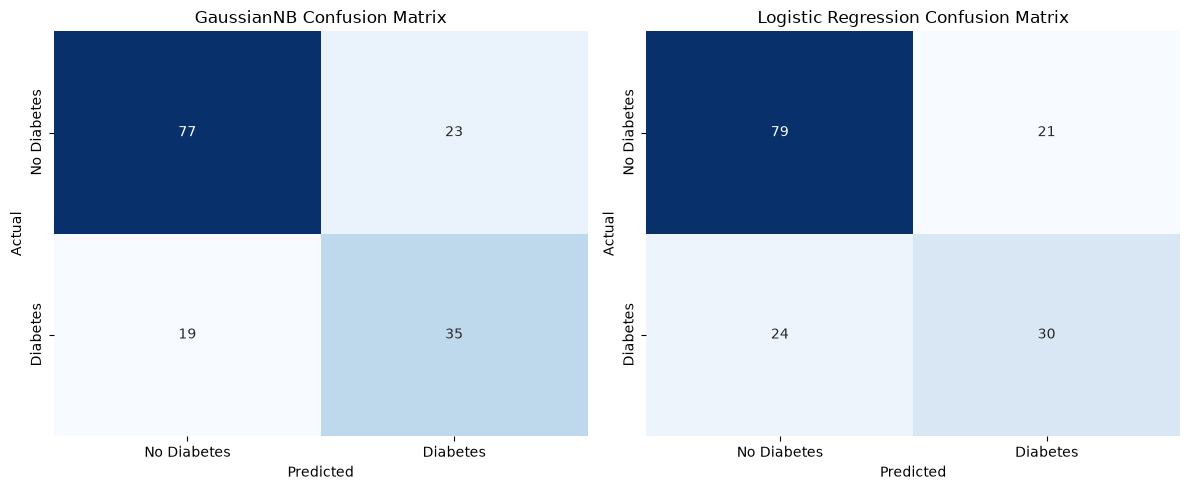

In [83]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_gnb = confusion_matrix(y_test, gnb_pred)
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'], ax=axes[0], cbar=False)
axes[0].set_title('GaussianNB Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_lr = confusion_matrix(y_test, logreg_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'], ax=axes[1], cbar=False)
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


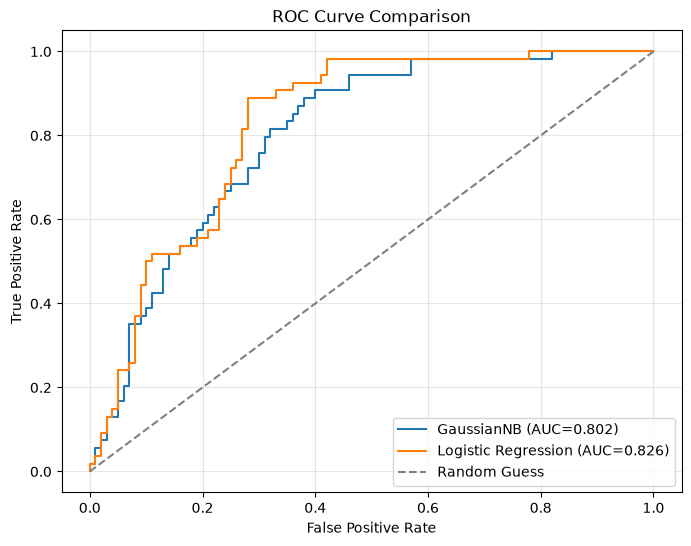

In [84]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.

plt.figure(figsize=(8, 6))

fpr_gnb, tpr_gnb, _ = roc_curve(y_test, gnb_proba)
auc_gnb = roc_auc_score(y_test, gnb_proba)
plt.plot(fpr_gnb, tpr_gnb, label=f'GaussianNB (AUC={auc_gnb:.3f})')

fpr_lr, tpr_lr, _ = roc_curve(y_test, logreg_proba)
auc_lr = roc_auc_score(y_test, logreg_proba)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()


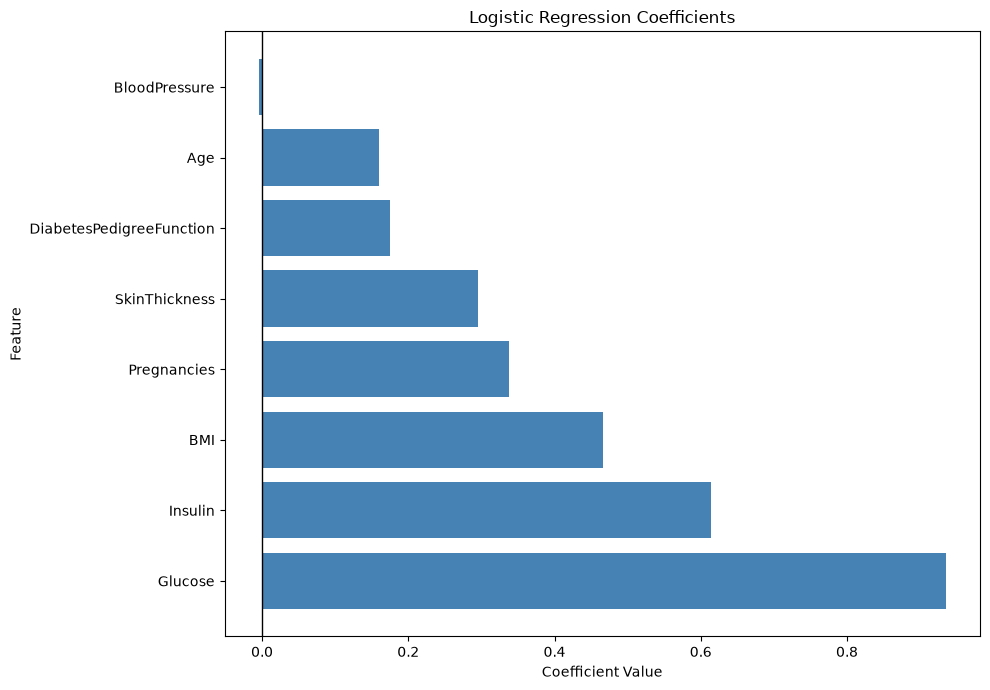

In [85]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.

feature_names = [col for col in data.columns if col != 'Outcome']
coefficients = logreg.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 7))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue')
plt.axvline(0, color='black', linewidth=1)
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


# 5. Analisis

Model GaussianNB memiliki skor metrik akurasi, precision, recall, dan F1-score yang lebih tinggi daripada LogisticRegression, walaupun memiliki nilai AUC yang lebih rendah. Hasil komputasi LogisticRegression menunjukkan koefisien yang positif untuk fitur "Age", "DiabetersPedigreeFunction", "SkinThickness", "Pregnancies", "BMI", "Insulin", dan "Glucose", tetapi memiliki koefisien negatif untuk fitur "BloodPressure".

# 6. Kesimpulan dan Saran

Kesimpulan:
Kedua model memiliki keunggulan pada beberapa metrik. Namun, dikarenakan dataset ini memiliki class imbalance, khususnya pada kelas negatif, metrik AUC menjadi kurang representatif karena berpotensi menyebabkan perbedaan jumlah false positive dan false negative yang signifikan. Performa metrik, seperti precision, recall, accuracy, dan F1-score, lebih ditekankan pada kasus ini.

Saran:
Good, I guess.